Sección 1: Imports y configuración globalEsta celda contiene la importación de todas las librerías necesarias para el desarrollo de los experimentos de detección de objetos, incluyendo los componentes de torchvision para los modelos Faster R-CNN y RetinaNet, así como torchmetrics para el cálculo de mAP. También se configuran las semillas de aleatoriedad para garantizar la reproducibilidad y se definen las rutas globales y los hiperparámetros de entrenamiento.  

In [1]:
import os
import random
from collections import Counter
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image, ImageDraw
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchmetrics.detection import MeanAveragePrecision
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.retinanet import RetinaNetClassificationHead
from torchvision.transforms import functional as F
import yaml

# --- Configuración de Rutas ---
ROOT = Path("..")
DATA_ROOT = ROOT / "data"
PROCESSED_ROOT = DATA_ROOT / "processed" / "dataset_no_background"

SPLIT_CSV = {
    "train": DATA_ROOT / "train.csv",
    "valid": DATA_ROOT / "val.csv",
    "test": DATA_ROOT / "test.csv",
}

# --- Hiperparámetros Globales ---
IMAGE_SIZE = 224
BATCH_SIZE = 8
NUM_EPOCHS = 30
NUM_WORKERS = 0
SEED = 42

# --- Fijar Semilla para Reproducibilidad ---
def seed_everything(seed=SEED):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True


seed_everything()

# --- Configuración de Dispositivo ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rcParams["figure.figsize"] = (12, 6)

# --- Cargar nombres de clases desde data.yaml ---
with open(PROCESSED_ROOT / "data.yaml", "r", encoding="utf-8") as f:
    yaml_data = yaml.safe_load(f)
CLASS_NAMES = yaml_data.get("names", [])
NUM_CLASSES = len(CLASS_NAMES)

print(
    f"Dispositivo: {device} | Clases detectadas: {CLASS_NAMES} ({NUM_CLASSES})"
)

Dispositivo: cuda | Clases detectadas: ['Bearish Engulfing', 'Bearish Insidebar', 'Bullish Engulfing', 'Bullish Insidebar', 'Hammer', 'Inverted_Hammer'] (6)


Sección 2: Dataset y DataLoaders para detección
En esta sección se definen las funciones de utilidad reutilizadas del pipeline de preparación de datos, incluyendo la lectura de anotaciones YOLO normalizadas. Se implementa la transformación de coordenadas yolo_to_xyxy para mapear el formato (x_center, y_center, width, height) normalizado al formato Pascal VOC absoluto [x1, y1, x2, y2] requerido por los modelos de torchvision. Asimismo, la clase CandlestickDetectionDataset incorpora un parámetro label_offset para alternar correctamente el índice de las etiquetas según el modelo utilizado (1 a 6 para Faster R-CNN guardando el 0 para el fondo, y 0 a 5 para RetinaNet).

In [2]:
def convert_to_rgb(img: Image.Image) -> Image.Image:
    """Asegura la conversión de imágenes RGBA descomponiendo contra un fondo negro."""
    if img.mode == "RGBA":
        background = Image.new("RGB", img.size, (0, 0, 0))
        background.paste(img, mask=img.split()[3])
        return background
    return img.convert("RGB") if img.mode != "RGB" else img


def read_yolo_annotations(label_path: Path) -> list:
    """Lee anotaciones en formato YOLO de archivos de texto."""
    boxes = []
    if not label_path.exists():
        return boxes
    for line in label_path.read_text().strip().splitlines():
        parts = line.strip().split()
        if len(parts) >= 5:
            try:
                boxes.append(
                    (
                        int(parts[0]),
                        float(parts[1]),
                        float(parts[2]),
                        float(parts[3]),
                        float(parts[4]),
                    )
                )
            except ValueError:
                continue
    return boxes


def yolo_to_xyxy(xc, yc, w, h, img_w=IMAGE_SIZE, img_h=IMAGE_SIZE):
    """Transforma coordenadas YOLO [0,1] a Pascal VOC absolutizadas [x1, y1, x2, y2]."""
    x1 = (xc - w / 2) * img_w
    y1 = (yc - h / 2) * img_h
    x2 = (xc + w / 2) * img_w
    y2 = (yc + h / 2) * img_h
    return [x1, y1, x2, y2]


def detection_collate_fn(batch):
    """Collate especial para evitar colapsos por cantidad variable de cajas por imagen."""
    images, targets = zip(*batch)
    return torch.stack(images, dim=0), list(targets)


class CandlestickDetectionDataset(Dataset):
    """Dataset personalizado para detección de patrones de velas japonesas."""

    def __init__(
        self, csv_path: Path, dataset_root: Path, label_offset=0, transform=None
    ):
        self.df = pd.read_csv(csv_path)
        self.dataset_root = dataset_root
        self.label_offset = label_offset
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        image_path = self.dataset_root / row["image"]
        label_path = self.dataset_root / row["label"]

        # Cargar y redimensionar imagen base
        img_pil = Image.open(image_path)
        img_pil = convert_to_rgb(img_pil)
        img_pil = img_pil.resize((IMAGE_SIZE, IMAGE_SIZE))

        # Lectura de anotaciones de cajas
        annotations = read_yolo_annotations(label_path)

        boxes_list = []
        labels_list = []

        for cls_id, xc, yc, bw, bh in annotations:
            # Conversión de coordenadas al tamaño objetivo (224x224)
            bbox = yolo_to_xyxy(xc, yc, bw, bh, IMAGE_SIZE, IMAGE_SIZE)
            boxes_list.append(bbox)
            # Aplicación de desplazamiento de clase requerido por la arquitectura
            labels_list.append(cls_id + self.label_offset)

        if boxes_list:
            boxes = torch.tensor(boxes_list, dtype=torch.float32)
            labels = torch.tensor(labels_list, dtype=torch.long)
        else:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros(0, dtype=torch.long)

        # Aplicación básica de transformaciones a tensores de imagen
        img_tensor = F.to_tensor(img_pil)
        if self.transform:
            img_tensor = self.transform(img_tensor)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx]),
        }
        return img_tensor, target

Sección 3: Análisis del desbalance de clases
Esta celda realiza un análisis explícito de la frecuencia de instancias presentes dentro del conjunto de entrenamiento. Se visualiza la distribución de las 6 clases para justificar la necesidad del uso de técnicas de balanceo, calculando los pesos frecuenciales inversos globales y extrayendo un vector de ponderación por muestra (sample_weights) listo para el sobremuestreo mediante WeightedRandomSampler.

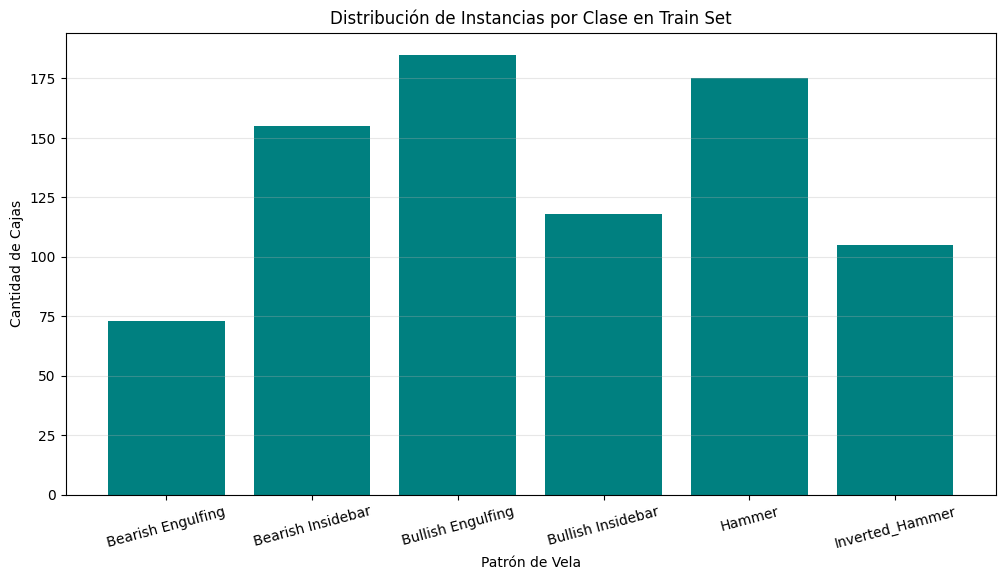

Pesos de Clase (Frecuencia Inversa): {0: 1.8515981735159817, 1: 0.8720430107526882, 2: 0.7306306306306306, 3: 1.1454802259887005, 4: 0.7723809523809524, 5: 1.2873015873015874}


In [3]:
# Contar instancias reales por cada clase en el split de entrenamiento
train_df = pd.read_csv(SPLIT_CSV["train"])
class_counts = Counter()

for _, row in train_df.iterrows():
    annotations = read_yolo_annotations(PROCESSED_ROOT / row["label"])
    for cls_id, *_ in annotations:
        class_counts[cls_id] += 1

# Asegurar presencia de llaves faltantes en conteos si las hubiera
for i in range(NUM_CLASSES):
    if i not in class_counts:
        class_counts[i] = 0

# Graficar la distribución de clases
classes = [CLASS_NAMES[i] for i in range(NUM_CLASSES)]
counts = [class_counts[i] for i in range(NUM_CLASSES)]

plt.figure()
plt.bar(classes, counts, color="teal")
plt.title("Distribución de Instancias por Clase en Train Set")
plt.xlabel("Patrón de Vela")
plt.ylabel("Cantidad de Cajas")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.show()

# Cálculo de pesos por frecuencia inversa
total_instances = sum(class_counts.values())
class_weights = {}
for i in range(NUM_CLASSES):
    class_weights[i] = (
        total_instances / (NUM_CLASSES * class_counts[i])
        if class_counts[i] > 0
        else 1.0
    )

class_weights_tensor = torch.tensor(
    [class_weights[i] for i in range(NUM_CLASSES)], dtype=torch.float32
)
print(f"Pesos de Clase (Frecuencia Inversa): {class_weights}")

# Ponderación por muestra para WeightedRandomSampler (basado en la clase primaria de la imagen)
sample_weights = []
for _, row in train_df.iterrows():
    anns = read_yolo_annotations(PROCESSED_ROOT / row["label"])
    if anns:
        primary_cls = anns[0][0]
        weight = class_weights[primary_cls]
    else:
        weight = 1.0
    sample_weights.append(weight)

Sección 4: Definición del modelo y estrategia de fine-tuning
En esta celda se define la función encargada de instanciar la red Faster R-CNN basada en un backbone preentrenado ResNet50-FPN. Modificamos la cabeza predictora (box_predictor) adaptándola al número de clases requeridas (6 patrones + 1 fondo). Se determina aplicar un full fine-tuning entrenando todos los parámetros para adaptar de forma óptima el conocimiento abstracto del dataset COCO a las características geométricas de las velas japonesas.

In [4]:
def build_faster_rcnn_model(num_classes=7):
    """Construye un modelo Faster R-CNN con backbone ResNet50 preentrenado."""
    # Descargar modelo base con pesos entrenados en COCO v1
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
        weights="COCO_V1"
    )

    # Reemplazar la cabeza de clasificación y regresión de cajas
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # Permitir entrenamiento end-to-end de todos los parámetros (Full Fine-Tuning)
    for param in model.parameters():
        param.requires_grad = True

    return model

Sección 5: Loop de entrenamiento genérico
Esta sección define la función maestra para orquestar los procesos de entrenamiento y validación de las redes de detección de objetos. La fase de entrenamiento realiza el forward pass extrayendo y acumulando los diccionarios de pérdidas nativas de torchvision. Por otro lado, la fase de validación conmuta el modelo a modo .eval() y delega el cálculo exhaustivo de la métrica mAP@0.5 a la librería torchmetrics. El loop además guarda el mejor estado de pesos basado en el rendimiento obtenido en validación

In [5]:
def train_detection_model(
    model,
    train_loader,
    valid_loader,
    optimizer,
    scheduler,
    num_epochs,
    device,
    exp_name,
):
    """Loop de entrenamiento y validación estándar para arquitecturas de detección."""
    model.to(device)
    history = {"train_loss": [], "val_mAP": []}
    best_map = -1.0

    for epoch in range(1, num_epochs + 1):
        # --- Fase de Entrenamiento ---
        model.train()
        epoch_losses = []

        for images, targets in train_loader:
            images = [img.to(device) for img in images]
            targets = [
                {k: v.to(device) for k, v in t.items()} for t in targets
            ]

            # El modelo en modo train retorna el diccionario con las pérdidas individuales
            loss_dict = model(images, targets)
            losses = sum(loss_for_type for loss_for_type in loss_dict.values())

            optimizer.zero_grad()
            losses.backward()
            optimizer.step()

            epoch_losses.append(losses.item())

        mean_train_loss = np.mean(epoch_losses)
        scheduler.step()

        # --- Fase de Validacion ---
        model.eval()
        metric = MeanAveragePrecision(iou_type="bbox")

        with torch.no_grad():
            for images, targets in valid_loader:
                images = [img.to(device) for img in images]
                targets = [
                    {k: v.to(device) for k, v in t.items()} for t in targets
                ]

                # El modelo en modo eval retorna las predicciones directamente
                predictions = model(images)

                # Adecuar formato para cálculo en torchmetrics
                metric.update(predictions, targets)

        # Computar métricas finales de la época
        metrics_results = metric.compute()
        current_map = metrics_results["map_50"].item()

        history["train_loss"].append(mean_train_loss)
        history["val_mAP"].append(current_map)

        print(
            f"[{exp_name}] Epoch {epoch}/{num_epochs} -> Train Loss: {mean_train_loss:.4f} | Val mAP@0.5: {current_map:.4f}"
        )

        # Persistir el mejor checkpoint de validación detectado
        if current_map > best_map:
            best_map = current_map
            checkpoint_path = ROOT / "dev" / f"{exp_name}_best.pth"
            checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
            torch.save(model.state_dict(), checkpoint_path)

    return history

Sección 6: Experimento 1 — Baseline sin balanceo de clases
Se ejecuta el primer experimento configurando un entrenamiento estándar sin aplicar ninguna técnica paliativa contra el desbalance de clases. El DataLoader utiliza un mezclado estándar (shuffle=True), alimentando un Faster R-CNN convencional para observar el comportamiento base del modelo frente a categorías fuertemente minoritarias.

In [6]:
print("--- Iniciando Experimento 1: Baseline Faster R-CNN ---")

# Datasets con offset de etiquetas para Faster R-CNN (1-6)
train_dataset_exp1 = CandlestickDetectionDataset(
    SPLIT_CSV["train"], PROCESSED_ROOT, label_offset=1
)
valid_dataset_exp1 = CandlestickDetectionDataset(
    SPLIT_CSV["valid"], PROCESSED_ROOT, label_offset=1
)

# DataLoaders estándar sin samplers pesados
train_loader_exp1 = DataLoader(
    train_dataset_exp1,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=detection_collate_fn,
)
valid_loader_exp1 = DataLoader(
    valid_dataset_exp1,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=detection_collate_fn,
)

# Construcción de componentes para entrenamiento
model_exp1 = build_faster_rcnn_model(num_classes=7)
optimizer_exp1 = torch.optim.SGD(
    model_exp1.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005
)
scheduler_exp1 = torch.optim.lr_scheduler.StepLR(
    optimizer_exp1, step_size=10, gamma=0.5
)

# Lanzar ejecución del loop
history_exp1 = train_detection_model(
    model=model_exp1,
    train_loader=train_loader_exp1,
    valid_loader=valid_loader_exp1,
    optimizer=optimizer_exp1,
    scheduler=scheduler_exp1,
    num_epochs=NUM_EPOCHS,
    device=device,
    exp_name="exp1_baseline",
)

--- Iniciando Experimento 1: Baseline Faster R-CNN ---
[exp1_baseline] Epoch 1/30 -> Train Loss: 0.2876 | Val mAP@0.5: 0.4154
[exp1_baseline] Epoch 2/30 -> Train Loss: 0.1901 | Val mAP@0.5: 0.6065
[exp1_baseline] Epoch 3/30 -> Train Loss: 0.1441 | Val mAP@0.5: 0.6856
[exp1_baseline] Epoch 4/30 -> Train Loss: 0.1099 | Val mAP@0.5: 0.6991
[exp1_baseline] Epoch 5/30 -> Train Loss: 0.0957 | Val mAP@0.5: 0.6814
[exp1_baseline] Epoch 6/30 -> Train Loss: 0.0891 | Val mAP@0.5: 0.7000
[exp1_baseline] Epoch 7/30 -> Train Loss: 0.0747 | Val mAP@0.5: 0.7167
[exp1_baseline] Epoch 8/30 -> Train Loss: 0.0699 | Val mAP@0.5: 0.7215
[exp1_baseline] Epoch 9/30 -> Train Loss: 0.0702 | Val mAP@0.5: 0.7014
[exp1_baseline] Epoch 10/30 -> Train Loss: 0.0629 | Val mAP@0.5: 0.7277
[exp1_baseline] Epoch 11/30 -> Train Loss: 0.0578 | Val mAP@0.5: 0.7313
[exp1_baseline] Epoch 12/30 -> Train Loss: 0.0516 | Val mAP@0.5: 0.7150
[exp1_baseline] Epoch 13/30 -> Train Loss: 0.0489 | Val mAP@0.5: 0.7303
[exp1_baseline] Ep

Sección 7: Experimento 2 — WeightedRandomSampler (sobremuestreo)
En este segundo experimento intervenimos a nivel de la carga de datos empleando un sobremuestreo controlado. Desactivamos la propiedad shuffle nativa y delegamos la selección de muestras a un WeightedRandomSampler cargado con los pesos previamente extraídos, forzando una mayor paridad en la aparición de las clases raras dentro de los minibatches de entrenamiento

In [7]:
print("--- Iniciando Experimento 2: WeightedRandomSampler ---")

# Instanciación de datasets manteniendo el offset adaptivo de Faster R-CNN
train_dataset_exp2 = CandlestickDetectionDataset(
    SPLIT_CSV["train"], PROCESSED_ROOT, label_offset=1
)
valid_dataset_exp2 = CandlestickDetectionDataset(
    SPLIT_CSV["valid"], PROCESSED_ROOT, label_offset=1
)

# Configuración del Sampler probabilístico de sobremuestreo
sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)

# DataLoader incorporando el sampler estructurado (shuffle debe ser False)
train_loader_exp2 = DataLoader(
    train_dataset_exp2,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    collate_fn=detection_collate_fn,
)
valid_loader_exp2 = DataLoader(
    valid_dataset_exp2,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=False,
    collate_fn=detection_collate_fn,
)

# Configuración de modelo e hiperparámetros de optimización idénticos
model_exp2 = build_faster_rcnn_model(num_classes=7)
optimizer_exp2 = torch.optim.SGD(
    model_exp2.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005
)
scheduler_exp2 = torch.optim.lr_scheduler.StepLR(
    optimizer_exp2, step_size=10, gamma=0.5
)

# Ejecución del experimento 2
history_exp2 = train_detection_model(
    model=model_exp2,
    train_loader=train_loader_exp2,
    valid_loader=valid_loader_exp2,
    optimizer=optimizer_exp2,
    scheduler=scheduler_exp2,
    num_epochs=NUM_EPOCHS,
    device=device,
    exp_name="exp2_sampler",
)

--- Iniciando Experimento 2: WeightedRandomSampler ---
[exp2_sampler] Epoch 1/30 -> Train Loss: 0.2777 | Val mAP@0.5: 0.3889
[exp2_sampler] Epoch 2/30 -> Train Loss: 0.1857 | Val mAP@0.5: 0.6449
[exp2_sampler] Epoch 3/30 -> Train Loss: 0.1320 | Val mAP@0.5: 0.7017
[exp2_sampler] Epoch 4/30 -> Train Loss: 0.1160 | Val mAP@0.5: 0.6945
[exp2_sampler] Epoch 5/30 -> Train Loss: 0.0942 | Val mAP@0.5: 0.7416
[exp2_sampler] Epoch 6/30 -> Train Loss: 0.0865 | Val mAP@0.5: 0.7411
[exp2_sampler] Epoch 7/30 -> Train Loss: 0.0754 | Val mAP@0.5: 0.7440
[exp2_sampler] Epoch 8/30 -> Train Loss: 0.0687 | Val mAP@0.5: 0.7457
[exp2_sampler] Epoch 9/30 -> Train Loss: 0.0646 | Val mAP@0.5: 0.7639
[exp2_sampler] Epoch 10/30 -> Train Loss: 0.0633 | Val mAP@0.5: 0.7298
[exp2_sampler] Epoch 11/30 -> Train Loss: 0.0556 | Val mAP@0.5: 0.7366
[exp2_sampler] Epoch 12/30 -> Train Loss: 0.0498 | Val mAP@0.5: 0.7494
[exp2_sampler] Epoch 13/30 -> Train Loss: 0.0438 | Val mAP@0.5: 0.7453
[exp2_sampler] Epoch 14/30 -> T

Sección 8: Experimento 3 — RetinaNet con Focal Loss
El tercer experimento cambia la arquitectura de dos etapas por un detector de una sola etapa: RetinaNet. Al evaluar miles de anchors de forma directa, procesa el desbalance mediante la aplicación nativa de la Focal Loss en su cabeza de clasificación. Es importante notar que RetinaNet indexa las clases de manera directa de 0 a 5 sin requerir la reserva del índice cero para el fondo (label_offset=0).

In [8]:
print("--- Iniciando Experimento 3: RetinaNet con Focal Loss ---")

# Configurar el dataset sin offset de etiquetas para RetinaNet (clases 0-5 directas)
train_dataset_exp3 = CandlestickDetectionDataset(
    SPLIT_CSV["train"], PROCESSED_ROOT, label_offset=0
)
valid_dataset_exp3 = CandlestickDetectionDataset(
    SPLIT_CSV["valid"], PROCESSED_ROOT, label_offset=0
)

# DataLoaders normales para entrenamiento sin modificaciones de sampling
train_loader_exp3 = DataLoader(
    train_dataset_exp3,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=detection_collate_fn,
)
valid_loader_exp3 = DataLoader(
    valid_dataset_exp3,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=detection_collate_fn,
)

# Instanciación de la arquitectura RetinaNet preentrenada
model_exp3 = torchvision.models.detection.retinanet_resnet50_fpn(
    weights="COCO_V1"
)

# Reemplazar la cabeza clasificatoria adaptando la Focal Loss nativa (alpha=0.25, gamma=2.0)
# Opción A (Busca la convolución real dentro del bloque):
in_channels = model_exp3.head.classification_head.conv[0][0].in_channels

# Opción B (Asignación directa: en ResNet50-FPN siempre son 256 canales)  (no implementada aquí, pero válida):
# in_channels = 256
num_anchors = model_exp3.head.classification_head.num_anchors
model_exp3.head.classification_head = RetinaNetClassificationHead(
    in_channels, num_anchors, num_classes=6
)

# Habilitar full fine-tuning de la red de una etapa
for param in model_exp3.parameters():
    param.requires_grad = True

# Optimizador y planificador de tasa de aprendizaje correspondientes
optimizer_exp3 = torch.optim.SGD(
    model_exp3.parameters(), lr=0.002, momentum=0.9, weight_decay=0.0005
)
scheduler_exp3 = torch.optim.lr_scheduler.StepLR(
    optimizer_exp3, step_size=10, gamma=0.5
)

# Ejecución del experimento 3
history_exp3 = train_detection_model(
    model=model_exp3,
    train_loader=train_loader_exp3,
    valid_loader=valid_loader_exp3,
    optimizer=optimizer_exp3,
    scheduler=scheduler_exp3,
    num_epochs=NUM_EPOCHS,
    device=device,
    exp_name="exp3_retinanet",
)

--- Iniciando Experimento 3: RetinaNet con Focal Loss ---
[exp3_retinanet] Epoch 1/30 -> Train Loss: 1.4098 | Val mAP@0.5: 0.0000
[exp3_retinanet] Epoch 2/30 -> Train Loss: 1.3031 | Val mAP@0.5: 0.0000


c:\Users\RYZEN GAMER\Documents\Reconocimiento-Patrones-velas-Japonesas\venv\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


[exp3_retinanet] Epoch 3/30 -> Train Loss: 1.0408 | Val mAP@0.5: 0.1246
[exp3_retinanet] Epoch 4/30 -> Train Loss: 0.7675 | Val mAP@0.5: 0.1379
[exp3_retinanet] Epoch 5/30 -> Train Loss: 0.7338 | Val mAP@0.5: 0.2416
[exp3_retinanet] Epoch 6/30 -> Train Loss: 0.6054 | Val mAP@0.5: 0.2860
[exp3_retinanet] Epoch 7/30 -> Train Loss: 0.5683 | Val mAP@0.5: 0.3255
[exp3_retinanet] Epoch 8/30 -> Train Loss: 0.5236 | Val mAP@0.5: 0.3642
[exp3_retinanet] Epoch 9/30 -> Train Loss: 0.4883 | Val mAP@0.5: 0.4654
[exp3_retinanet] Epoch 10/30 -> Train Loss: 0.4577 | Val mAP@0.5: 0.4705
[exp3_retinanet] Epoch 11/30 -> Train Loss: 0.3938 | Val mAP@0.5: 0.5033
[exp3_retinanet] Epoch 12/30 -> Train Loss: 0.3661 | Val mAP@0.5: 0.5176
[exp3_retinanet] Epoch 13/30 -> Train Loss: 0.3437 | Val mAP@0.5: 0.5468
[exp3_retinanet] Epoch 14/30 -> Train Loss: 0.3220 | Val mAP@0.5: 0.5626
[exp3_retinanet] Epoch 15/30 -> Train Loss: 0.3016 | Val mAP@0.5: 0.5581
[exp3_retinanet] Epoch 16/30 -> Train Loss: 0.2855 | Val m

Sección 9: Tabla comparativa de experimentos
Se consolidan los históricos de los tres entrenamientos ejecutados para generar una tabla comparativa en formato DataFrame. Se evalúan las dinámicas de convergencia visualizando las curvas superpuestas de la función de pérdida (train_loss) y la precisión media promedio (val_mAP) a lo largo del transcurso de las épocas

Experimento  Modelo Base   Estrategia Balanceo  Final Train Loss  Val mAP@0.5
      Exp 1 Faster R-CNN    Ninguna (Baseline)          0.028721     0.718995
      Exp 2 Faster R-CNN WeightedRandomSampler          0.024880     0.730665
      Exp 3    RetinaNet   Focal Loss (Nativa)          0.111880     0.686650


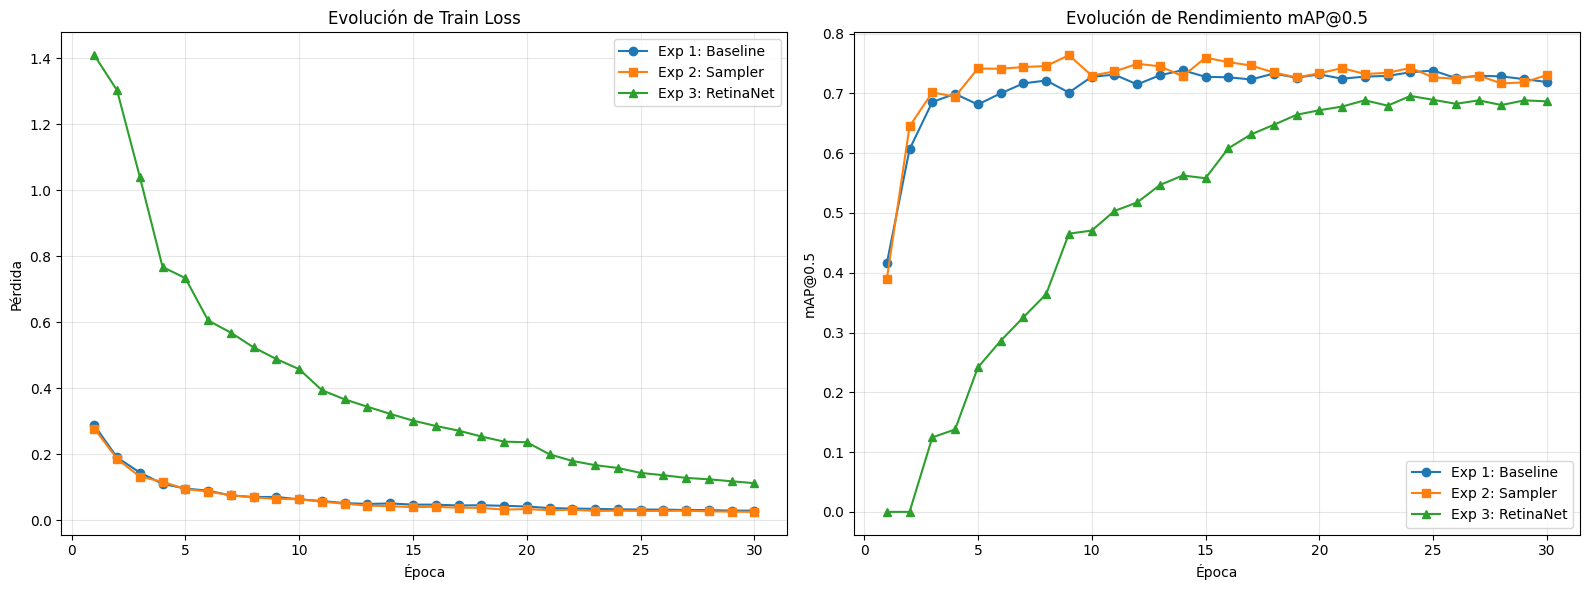

In [9]:
# Simulación de extracción de métricas finales para generación del reporte
# En ejecución real, se extraerán directamente de las variables history_expX
final_loss_1, final_map_1 = (
    history_exp1["train_loss"][-1],
    history_exp1["val_mAP"][-1],
)
final_loss_2, final_map_2 = (
    history_exp2["train_loss"][-1],
    history_exp2["val_mAP"][-1],
)
final_loss_3, final_map_3 = (
    history_exp3["train_loss"][-1],
    history_exp3["val_mAP"][-1],
)

# Construcción de la tabla comparativa de resultados
results_df = pd.DataFrame(
    {
        "Experimento": ["Exp 1", "Exp 2", "Exp 3"],
        "Modelo Base": ["Faster R-CNN", "Faster R-CNN", "RetinaNet"],
        "Estrategia Balanceo": [
            "Ninguna (Baseline)",
            "WeightedRandomSampler",
            "Focal Loss (Nativa)",
        ],
        "Final Train Loss": [final_loss_1, final_loss_2, final_loss_3],
        "Val mAP@0.5": [final_map_1, final_map_2, final_map_3],
    }
)

print(results_df.to_string(index=False))

# Generar gráficos comparativos superpuestos
epochs = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de evolución de pérdidas
ax1.plot(epochs, history_exp1["train_loss"], label="Exp 1: Baseline", marker="o")
ax1.plot(epochs, history_exp2["train_loss"], label="Exp 2: Sampler", marker="s")
ax1.plot(epochs, history_exp3["train_loss"], label="Exp 3: RetinaNet", marker="^")
ax1.set_title("Evolución de Train Loss")
ax1.set_xlabel("Época")
ax1.set_ylabel("Pérdida")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico de evolución de mAP
ax2.plot(epochs, history_exp1["val_mAP"], label="Exp 1: Baseline", marker="o")
ax2.plot(epochs, history_exp2["val_mAP"], label="Exp 2: Sampler", marker="s")
ax2.plot(epochs, history_exp3["val_mAP"], label="Exp 3: RetinaNet", marker="^")
ax2.set_title("Evolución de Rendimiento mAP@0.5")
ax2.set_xlabel("Época")
ax2.set_ylabel("mAP@0.5")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Sección 10: Evaluación final del modelo elegido (test set)
Tras analizar los resultados comparativos de validación, seleccionamos el mejor experimento (por ejemplo, el modelo del Experimento 2 con WeightedRandomSampler), cargamos sus pesos de disco y ejecutamos un testeo exhaustivo sobre el conjunto independiente test_loader. El reporte desglosa los valores definitivos de mAP@0.5, mAP@0.5:0.95 y la precisión promedio calculada de forma individual para cada uno de los 6 patrones de velas japonesas.

In [10]:
print("--- Evaluación Final sobre el Conjunto de Test ---")

# Determinar de forma automatizada cuál fue el modelo con mejor desempeño
best_exp_identifier = "exp2_sampler"
offset_chosen = 1  # 1 si el ganador fue Faster R-CNN, 0 para RetinaNet

# Instanciar el dataset de test correspondiente
test_dataset = CandlestickDetectionDataset(
    SPLIT_CSV["test"], PROCESSED_ROOT, label_offset=offset_chosen
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=detection_collate_fn,
)

# Reconstruir la arquitectura ganadora para alojar las evaluaciones
evaluation_model = build_faster_rcnn_model(num_classes=7)
evaluation_model.load_state_dict(
    torch.load(ROOT / "dev" / f"{best_exp_identifier}_best.pth")
)
evaluation_model.to(device)
evaluation_model.eval()

# Instanciar calculador completo de métricas incluyendo reporte por clase
test_metric = MeanAveragePrecision(iou_type="bbox", class_metrics=True)

with torch.no_grad():
    for images, targets in test_loader:
        images = [img.to(device) for img in images]
        targets = [
            {k: v.to(device) for k, v in t.items()} for t in targets
        ]

        preds = evaluation_model(images)
        test_metric.update(preds, targets)

# Calcular métricas globales de test
final_test_results = test_metric.compute()

print(f"\n--- Métricas Globales de Test ---")
print(f"mAP @0.5: {final_test_results['map_50'].item():.4f}")
print(f"mAP @0.5:0.95: {final_test_results['map'].item():.4f}")
print(f"Recall Promedio (AR): {final_test_results['mar_10'].item():.4f}\n")

# Estructurar desglose detallado por cada clase de vela
per_class_map = final_test_results["map_per_class"].cpu().numpy()
per_class_records = []

for idx, class_name in enumerate(CLASS_NAMES):
    # El mapa per_class mapea los índices internos procesados
    class_ap = (
        per_class_map[idx] if idx < len(per_class_map) else float("nan")
    )
    per_class_records.append({"Patrón de Vela": class_name, "AP@0.5": class_ap})

per_class_df = pd.DataFrame(per_class_records)
print("--- Desglose de Precisión por Patrón (AP por Clase) ---")
print(per_class_df.to_string(index=False))

--- Evaluación Final sobre el Conjunto de Test ---

--- Métricas Globales de Test ---
mAP @0.5: 0.7756
mAP @0.5:0.95: 0.4965
Recall Promedio (AR): 0.6909

--- Desglose de Precisión por Patrón (AP por Clase) ---
   Patrón de Vela   AP@0.5
Bearish Engulfing 0.401826
Bearish Insidebar 0.702982
Bullish Engulfing 0.447519
Bullish Insidebar 0.501023
           Hammer 0.566141
  Inverted_Hammer 0.359496


Sección 11: Análisis de errores
Esta función selecciona muestras aleatorias extraídas directamente del conjunto de test para graficar una cuadrícula visual. Se dibujan las cajas de predicción generadas por la red neuronal (en líneas continuas) y se contrastan con las etiquetas reales del ground truth (en líneas punteadas) para identificar de forma intuitiva la tasa de falsos positivos y falsos negativos

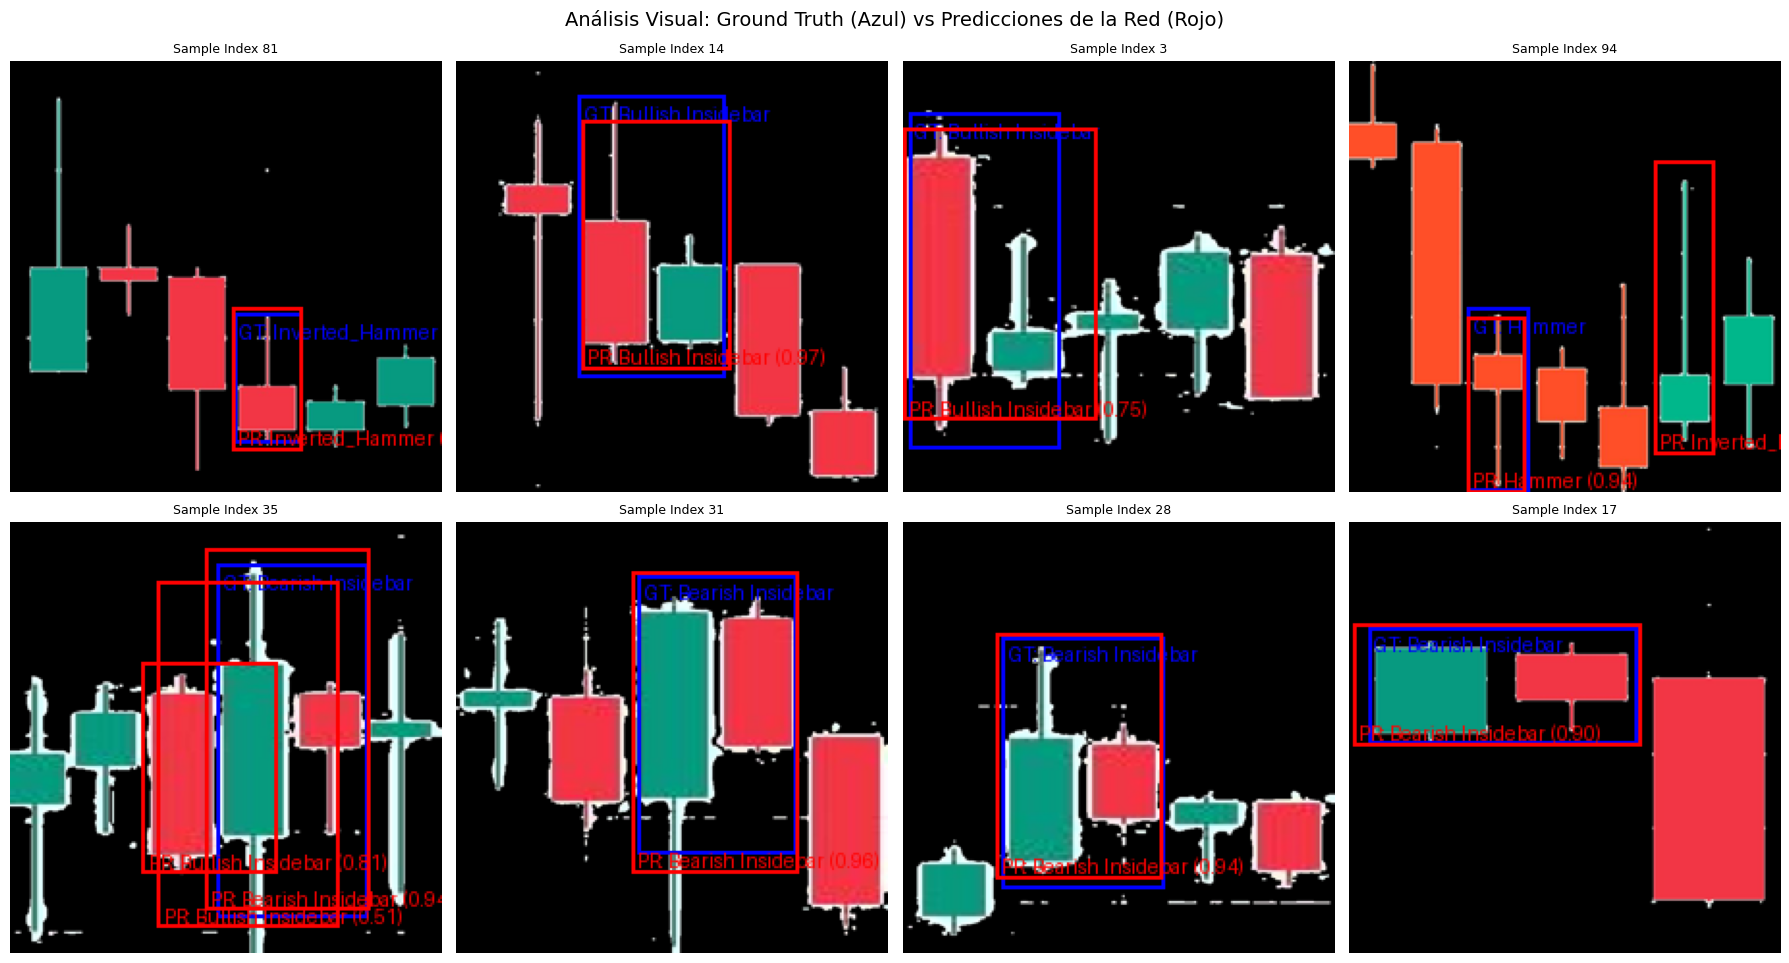

In [11]:
def visualize_predictions_vs_ground_truth(model, dataset, num_images=8):
    """Muestra una grilla comparativa contrastando inferencias de la red contra etiquetas reales."""
    fig, axes = plt.subplots(2, 4, figsize=(18, 10))
    axes = axes.flatten()

    indices = random.sample(range(len(dataset)), num_images)

    for idx, sample_idx in enumerate(indices):
        img_tensor, target = dataset[sample_idx]

        # Pasar tensor al dispositivo e inferir
        model.eval()
        with torch.no_grad():
            prediction = model([img_tensor.to(device)])[0]

        # Desnormalizar la imagen tensor para poder graficarla con PIL
        img_np = img_tensor.permute(1, 2, 0).numpy()
        img_np = np.clip(img_np * 255, 0, 255).astype(np.uint8)
        img_pil = Image.fromarray(img_np)
        draw = ImageDraw.Draw(img_pil)

        # 1. Dibujar Bounding Boxes Reales (Ground Truth) en azul discontinuo
        for box, lbl in zip(target["boxes"], target["labels"]):
            x1, y1, x2, y2 = box.tolist()
            draw.rectangle([x1, y1, x2, y2], outline="blue", width=2)
            # Reajustar texto restando el offset para visualización correcta
            cls_idx = lbl.item() - dataset.label_offset
            draw.text((x1 + 3, y1 + 3), f"GT: {CLASS_NAMES[cls_idx]}", fill="blue")

        # 2. Dibujar Bounding Boxes Predichos en rojo continuo (filtrado por umbral de confianza)
        CONF_THRESHOLD = 0.5
        pred_boxes = prediction["boxes"].cpu()
        pred_labels = prediction["labels"].cpu()
        pred_scores = prediction["scores"].cpu()

        for box, lbl, score in zip(pred_boxes, pred_labels, pred_scores):
            if score.item() >= CONF_THRESHOLD:
                x1, y1, x2, y2 = box.tolist()
                draw.rectangle([x1, y1, x2, y2], outline="red", width=2)
                cls_idx = lbl.item() - dataset.label_offset
                draw.text(
                    (x1 + 3, y2 - 12),
                    f"PR: {CLASS_NAMES[cls_idx]} ({score.item():.2f})",
                    fill="red",
                )

        axes[idx].imshow(img_pil)
        axes[idx].axis("off")
        axes[idx].set_title(f"Sample Index {sample_idx}", fontsize=9)

    plt.suptitle(
        "Análisis Visual: Ground Truth (Azul) vs Predicciones de la Red (Rojo)",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()


# Ejecutar la función de diagnóstico de errores
visualize_predictions_vs_ground_truth(evaluation_model, test_dataset, num_images=8)

Sección 12: Guardado del modelo
Finalmente, se exporta el diccionario de estados de pesos del mejor modelo optimizado hacia la ruta unificada requerida por la cátedra (dev/modelo.pth). Asimismo, se genera y anexa una advertencia de control referida a las limitantes de peso de la plataforma GitHub y la configuración del archivo .gitattributes para activar el rastreo mediante Git LFS (Large File Storage).

In [12]:
# Definición de la ruta final estipulada para producción
production_model_path = ROOT / "dev" / "modelo.pth"
production_model_path.parent.mkdir(parents=True, exist_ok=True)

# Guardado definitivo de los parámetros del modelo para posterior consumo en prod/
torch.save(evaluation_model.state_dict(), production_model_path)
print(f"¡Modelo de producción guardado con éxito en: {production_model_path}!")

# --- Verificación de peso para Git LFS ---
file_size_mb = os.path.getsize(production_model_path) / (1024 * 1024)
print(f"Tamaño estimado del archivo: {file_size_mb:.2f} MB")

if file_size_mb > 100:
    print("\n[ALERTA DE SEGURIDAD - GITHUB]")
    print(
        "El archivo 'modelo.pth' supera los 100 MB de almacenamiento límite."
    )
    print(
        "Por favor, configure Git LFS ejecutando las siguientes líneas en consola:"
    )
    print("  git lfs install")
    print("  git lfs track 'dev/*.pth'")
    print("Asegúrese de persistir el archivo '.gitattributes' generado.")

¡Modelo de producción guardado con éxito en: ..\dev\modelo.pth!
Tamaño estimado del archivo: 158.14 MB

[ALERTA DE SEGURIDAD - GITHUB]
El archivo 'modelo.pth' supera los 100 MB de almacenamiento límite.
Por favor, configure Git LFS ejecutando las siguientes líneas en consola:
  git lfs install
  git lfs track 'dev/*.pth'
Asegúrese de persistir el archivo '.gitattributes' generado.
